In [15]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("/Net/Groups/BSI/scratch/ppapastefanou/simulations/QPy/isimip/on27_ruf/post/plots/ssp585_total_veg_c.csv")
df = pd.read_csv("/Net/Groups/BSI/scratch/ppapastefanou/simulations/QPy/isimip/on27_ruf/post/plots/ssp370_gpp_avg.csv")


# y = df["y"]
# X = df.drop(columns=["y"])


In [16]:
y = df['gpp']
y

0      4.248060
1      4.158340
2      3.992057
3      3.986580
4      3.931103
         ...   
198    4.258770
199    4.119575
200    3.830201
201    4.108004
202    4.167428
Name: gpp, Length: 203, dtype: float64

In [17]:
X = df[['k_xylem_sats',
       'kappa_stem', 'kappa_leaf', 'k_latosa', 'g0', 'g1', 'psi50_close',
       'root_dist', 'silt', 'sand', 'root_scale', 'slope_leaf_close',
       'gdd_t_air_threshold', 'gdd_t_air_req', 'k_gdd', 'rtos_s']]

In [18]:
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)
importances = rf.feature_importances_

In [19]:
df_importance = pd.DataFrame({
    "variable": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print(df_importance)

               variable  importance
3              k_latosa    0.789532
6           psi50_close    0.120636
10           root_scale    0.029737
5                    g1    0.011387
8                  silt    0.009992
1            kappa_stem    0.007649
7             root_dist    0.007053
9                  sand    0.006942
2            kappa_leaf    0.006509
4                    g0    0.005341
0          k_xylem_sats    0.005223
11     slope_leaf_close    0.000000
12  gdd_t_air_threshold    0.000000
13        gdd_t_air_req    0.000000
14                k_gdd    0.000000
15               rtos_s    0.000000


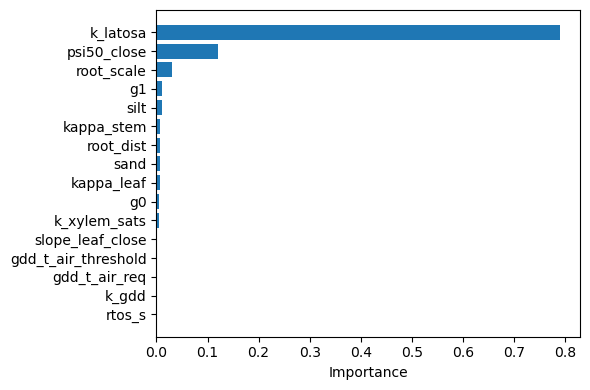

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.barh(df_importance["variable"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


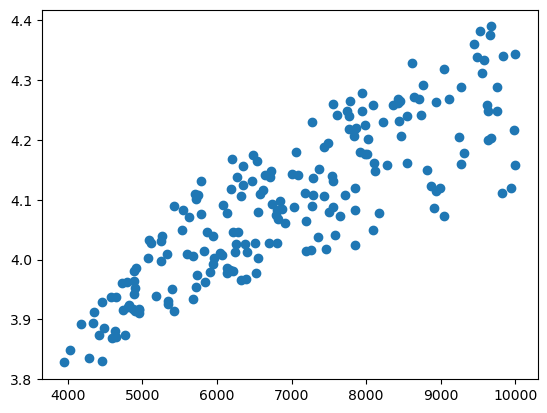

In [22]:
plt.scatter(df[ 'k_latosa'], df['gpp'])